# DÉTECTION AUTOMATIQUE DE MALADIES DES PLANTES (TOMATES)

## CONTEXTE

**Projet de classification d'images pour diagnostiquer automatiquement les maladies des plantes**

**Cas des feuilles de tomates**

Dataset: 4 classes
- Tomato_healthy (1591 images)
- Tomato_Septoria_leaf_spot (1771 images)
- Tomato_Tomato_mosaic_virus (373 images)
- Tomato_Bacterial_spot (2127 images)

# IMPORTATION DES BIBLIOTHEQUES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
import warnings
warnings.filterwarnings('ignore')

# Configuration de l'affichage
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Bibliothèques importées avec succès")

✓ Bibliothèques importées avec succès


# PARTIE 1: CONSTITUTION ET EXPLORATION DU DATASET

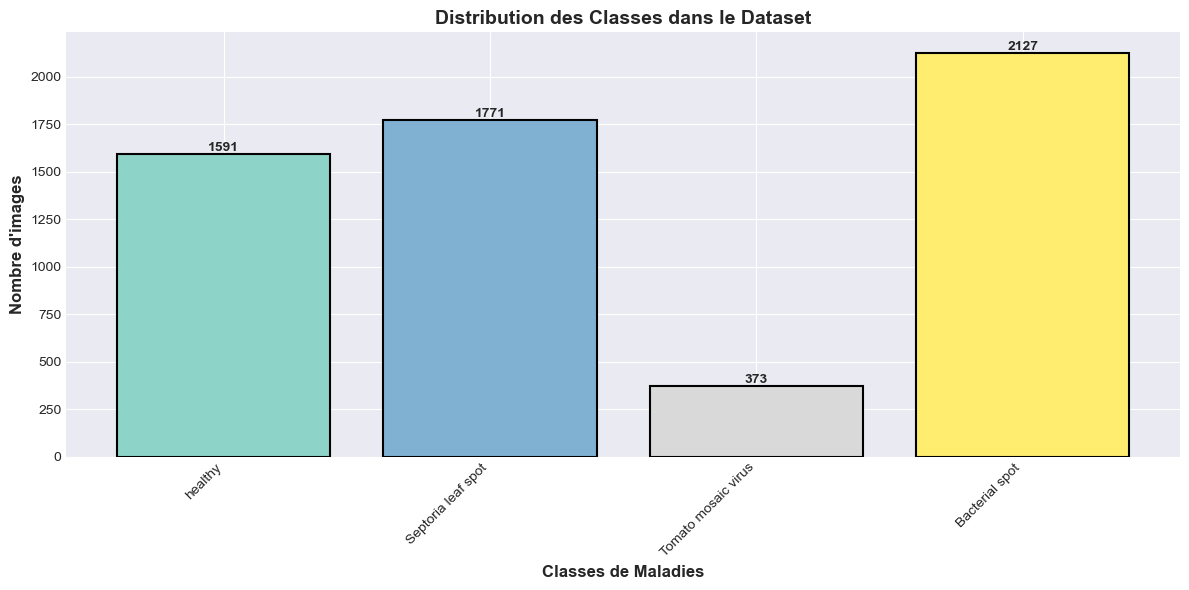


 STATISTIQUES DU DATASET:
Total d'images: 5862
Classe majoritaire: Tomato___Bacterial_spot (2127 images)
Classe minoritaire: Tomato___Tomato_mosaic_virus (373 images)
Déséquilibre: ratio 5.70:1


In [2]:
# Chemins vers vos dossiers d'images
BASE_PATH = "data/"  # À MODIFIER selon votre structure
CLASSES = {
    'Tomato___healthy': 1591,
    'Tomato___Septoria_leaf_spot': 1771,
    'Tomato___Tomato_mosaic_virus': 373,
    'Tomato___Bacterial_spot': 2127
}

def load_dataset(base_path, max_images_per_class=None):
    """
    Charge les images du dataset et retourne les images avec leurs labels
    
    Args:
        base_path: chemin vers le dossier parent contenant les sous-dossiers de classes
        max_images_per_class: nombre max d'images par classe (pour équilibrage)
    
    Returns:
        images: liste d'images
        labels: liste de labels correspondants
    """
    images = []
    labels = []
    
    for class_name in CLASSES.keys():
        class_path = os.path.join(base_path, class_name)
        image_files = os.listdir(class_path)
        
        # Limiter le nombre d'images si spécifié (équilibrage)
        if max_images_per_class:
            image_files = image_files[:max_images_per_class]
        
        for img_file in image_files:
            img_path = os.path.join(class_path, img_file)
            img = cv2.imread(img_path)
            if img is not None:
                images.append(img)
                labels.append(class_name)
    
    return images, labels

# Visualisation de la distribution des classes
def visualize_class_distribution():
    """Affiche la distribution des classes dans le dataset"""
    fig, ax = plt.subplots(figsize=(12, 6))
    
    classes = list(CLASSES.keys())
    counts = list(CLASSES.values())
    colors = plt.cm.Set3(np.linspace(0, 1, len(classes)))
    
    bars = ax.bar(range(len(classes)), counts, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_xlabel('Classes de Maladies', fontsize=12, fontweight='bold')
    ax.set_ylabel('Nombre d\'images', fontsize=12, fontweight='bold')
    ax.set_title('Distribution des Classes dans le Dataset', fontsize=14, fontweight='bold')
    ax.set_xticks(range(len(classes)))
    ax.set_xticklabels([c.replace('Tomato___', '').replace('_', ' ') for c in classes], 
                        rotation=45, ha='right')
    
    # Ajouter les valeurs sur les barres
    for i, (bar, count) in enumerate(zip(bars, counts)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{count}',
                ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("\n STATISTIQUES DU DATASET:")
    print(f"Total d'images: {sum(counts)}")
    print(f"Classe majoritaire: {max(CLASSES, key=CLASSES.get)} ({max(counts)} images)")
    print(f"Classe minoritaire: {min(CLASSES, key=CLASSES.get)} ({min(counts)} images)")
    print(f"Déséquilibre: ratio {max(counts)/min(counts):.2f}:1")

visualize_class_distribution()

# PARTIE : PRÉTRAITEMENT ET SEGMENTATION

In [3]:
def preprocess_image(image, target_size=(256, 256)):
    """
    Prétraite une image: redimensionnement et normalisation
    
    Args:
        image: image BGR d'entrée
        target_size: taille cible (largeur, hauteur)
    
    Returns:
        image redimensionnée et normalisée
    """
    # Redimensionner
    resized = cv2.resize(image, target_size)
    return resized

def segment_leaf_grabcut(image):
    """
    Segmente la feuille du fond en utilisant l'algorithme GrabCut
    
    Args:
        image: image BGR d'entrée
    
    Returns:
        image avec fond noir et feuille segmentée
    """
    # Créer un rectangle initial (80% de l'image)
    h, w = image.shape[:2]
    rect = (int(w*0.1), int(h*0.1), int(w*0.8), int(h*0.8))
    
    # Initialiser les masques pour GrabCut
    mask = np.zeros(image.shape[:2], np.uint8)
    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)
    
    # Appliquer GrabCut
    cv2.grabCut(image, mask, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)
    
    # Créer le masque final (0 et 2 = fond, 1 et 3 = avant-plan)
    mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')
    
    # Appliquer le masque
    segmented = image * mask2[:, :, np.newaxis]
    
    return segmented

def segment_leaf_color(image):
    """
    Segmente la feuille en utilisant la segmentation par couleur (méthode alternative plus rapide)
    
    Args:
        image: image BGR d'entrée
    
    Returns:
        image avec fond noir et feuille segmentée
    """
    # Convertir en HSV
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    # Définir la plage de couleurs vertes (feuilles)
    lower_green = np.array([25, 40, 40])
    upper_green = np.array([90, 255, 255])
    
    # Créer le masque
    mask = cv2.inRange(hsv, lower_green, upper_green)
    
    # Opérations morphologiques pour nettoyer le masque
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    
    # Appliquer le masque
    segmented = cv2.bitwise_and(image, image, mask=mask)
    
    return segmented

def detect_affected_areas(image):
    """
    Détecte les zones affectées (taches, décolorations) sur la feuille
    
    Args:
        image: image BGR segmentée
    
    Returns:
        masque binaire des zones affectées
    """
    # Convertir en LAB (meilleur pour détecter les variations de couleur)
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    
    # Extraire le canal a (vert-rouge) qui montre bien les taches
    a_channel = lab[:, :, 1]
    
    # Seuillage adaptatif pour détecter les anomalies
    _, thresh = cv2.threshold(a_channel, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    return thresh

# Fonction de visualisation du preprocessing
def visualize_preprocessing(image):
    """Visualise les différentes étapes du prétraitement"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Image originale
    axes[0, 0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title('1. Image Originale', fontweight='bold')
    axes[0, 0].axis('off')
    
    # Redimensionnée
    resized = preprocess_image(image)
    axes[0, 1].imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
    axes[0, 1].set_title('2. Redimensionnée (256x256)', fontweight='bold')
    axes[0, 1].axis('off')
    
    # Segmentation par couleur
    seg_color = segment_leaf_color(resized)
    axes[0, 2].imshow(cv2.cvtColor(seg_color, cv2.COLOR_BGR2RGB))
    axes[0, 2].set_title('3. Segmentation (Couleur)', fontweight='bold')
    axes[0, 2].axis('off')
    
    # Conversion HSV
    hsv = cv2.cvtColor(resized, cv2.COLOR_BGR2HSV)
    axes[1, 0].imshow(hsv)
    axes[1, 0].set_title('4. Espace HSV', fontweight='bold')
    axes[1, 0].axis('off')
    
    # Zones affectées
    affected = detect_affected_areas(seg_color)
    axes[1, 1].imshow(affected, cmap='hot')
    axes[1, 1].set_title('5. Zones Affectées Détectées', fontweight='bold')
    axes[1, 1].axis('off')
    
    # Overlay des zones affectées
    overlay = resized.copy()
    overlay[affected > 0] = [0, 0, 255]  # Rouge pour les zones affectées
    result = cv2.addWeighted(resized, 0.7, overlay, 0.3, 0)
    axes[1, 2].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    axes[1, 2].set_title('6. Overlay des Anomalies', fontweight='bold')
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

print("\n✓ Fonctions de prétraitement définies")
print("Utilisez visualize_preprocessing(image) pour voir les étapes")



✓ Fonctions de prétraitement définies
Utilisez visualize_preprocessing(image) pour voir les étapes


## TEST DE LA SEGEMENTATION ET DU PRETRAITEMENT

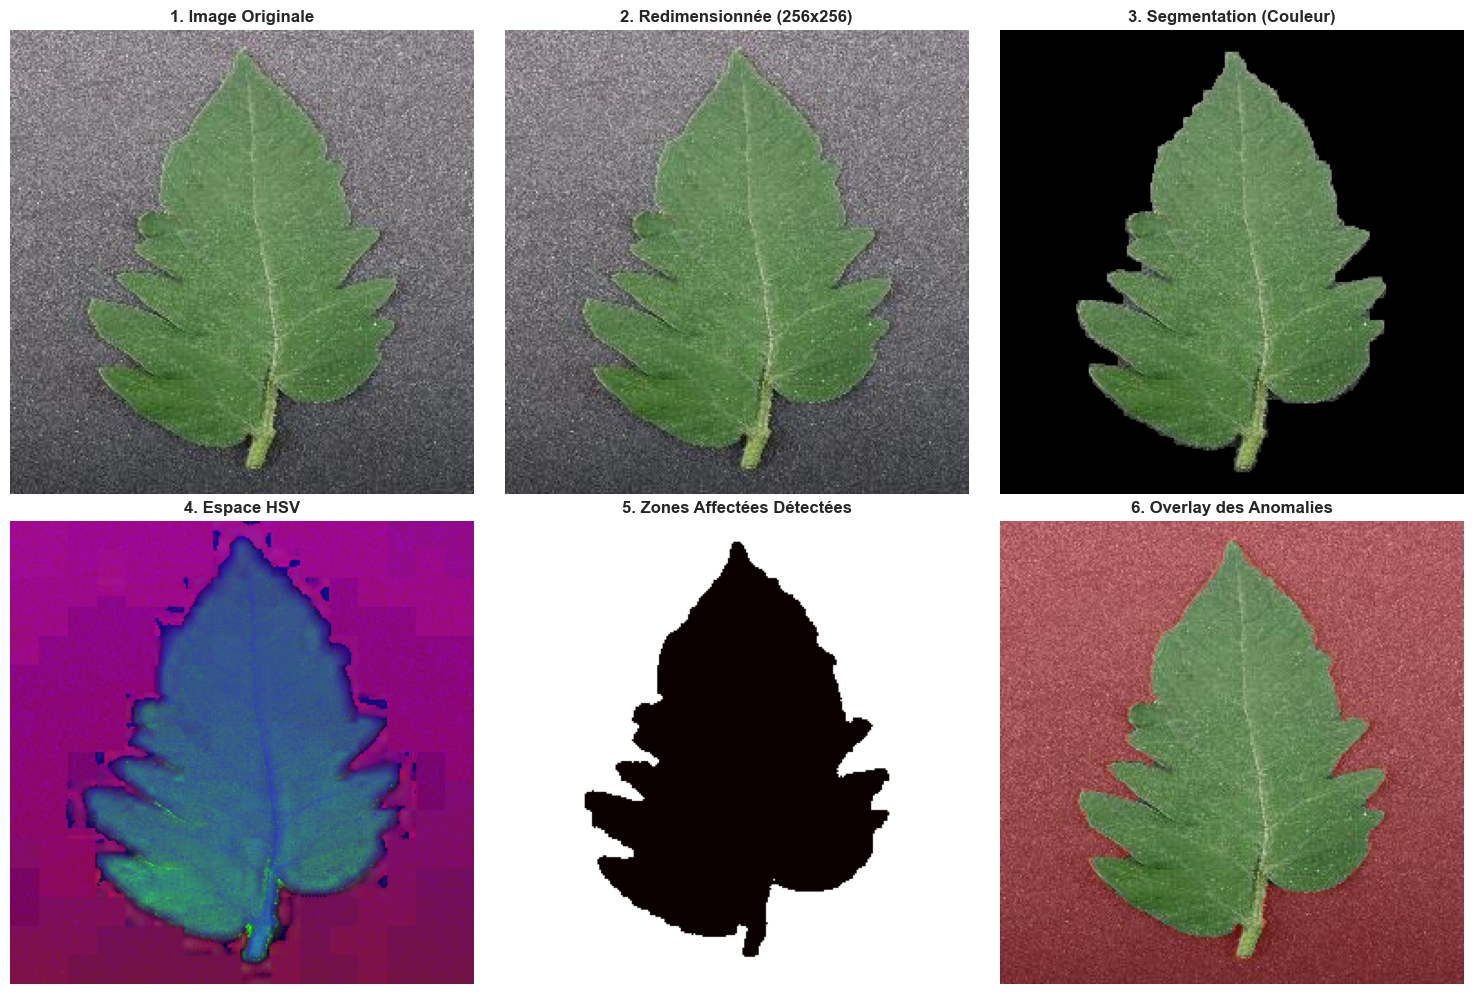

In [4]:
image_path = "data/Tomato___healthy/000bf685-b305-408b-91f4-37030f8e62db___GH_HL Leaf 308.1.jpg"
image = cv2.imread(image_path)

visualize_preprocessing(image)


# PARTIE 3: EXTRACTION DE CARACTÉRISTIQUES

In [5]:
def extract_color_features(image):
    """
    Extrait les caractéristiques de couleur (histogrammes HSV et LAB)
    
    Args:
        image: image BGR
    
    Returns:
        vecteur de caractéristiques de couleur (108 dimensions)
    """
    features = []
    
    # Convertir en HSV
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    # Calculer les histogrammes pour chaque canal HSV
    for i in range(3):
        hist = cv2.calcHist([hsv], [i], None, [16], [0, 256])
        hist = hist.flatten()
        hist = hist / (hist.sum() + 1e-7)  # Normalisation
        features.extend(hist)
    
    # Convertir en LAB
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    
    # Calculer les histogrammes pour chaque canal LAB
    for i in range(3):
        hist = cv2.calcHist([lab], [i], None, [16], [0, 256])
        hist = hist.flatten()
        hist = hist / (hist.sum() + 1e-7)  # Normalisation
        features.extend(hist)
    
    # Statistiques de couleur
    for i in range(3):
        features.append(np.mean(hsv[:, :, i]))
        features.append(np.std(hsv[:, :, i]))
        features.append(np.mean(lab[:, :, i]))
        features.append(np.std(lab[:, :, i]))
    
    return np.array(features)

def extract_texture_features(image):
    """
    Extrait les caractéristiques de texture (LBP et GLCM)
    
    Args:
        image: image BGR
    
    Returns:
        vecteur de caractéristiques de texture
    """
    features = []
    
    # Convertir en niveaux de gris
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Local Binary Pattern (LBP)
    radius = 3
    n_points = 8 * radius
    lbp = local_binary_pattern(gray, n_points, radius, method='uniform')
    
    # Histogramme LBP
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=n_points + 2, range=(0, n_points + 2))
    lbp_hist = lbp_hist.astype(float)
    lbp_hist /= (lbp_hist.sum() + 1e-7)
    features.extend(lbp_hist)
    
    # Gray Level Co-occurrence Matrix (GLCM)
    # Normaliser l'image en 8 niveaux de gris pour GLCM
    gray_glcm = (gray / 32).astype(np.uint8)
    
    # Calculer GLCM pour différentes directions
    distances = [1]
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    
    glcm = graycomatrix(gray_glcm, distances, angles, levels=8, symmetric=True, normed=True)
    
    # Extraire les propriétés GLCM
    properties = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']
    for prop in properties:
        feature = graycoprops(glcm, prop).ravel()
        features.extend(feature)
    
    return np.array(features)

def extract_shape_features(image):
    """
    Extrait les caractéristiques de forme (contours, moments)
    
    Args:
        image: image BGR
    
    Returns:
        vecteur de caractéristiques de forme
    """
    features = []
    
    # Convertir en niveaux de gris
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Seuillage
    _, binary = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    
    # Trouver les contours
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if len(contours) > 0:
        # Prendre le plus grand contour
        main_contour = max(contours, key=cv2.contourArea)
        
        # Aire et périmètre
        area = cv2.contourArea(main_contour)
        perimeter = cv2.arcLength(main_contour, True)
        
        # Ratio circularité
        if perimeter > 0:
            circularity = 4 * np.pi * area / (perimeter ** 2)
        else:
            circularity = 0
        
        # Moments de Hu
        moments = cv2.moments(main_contour)
        hu_moments = cv2.HuMoments(moments).flatten()
        
        # Log transformation des moments de Hu
        hu_moments = -np.sign(hu_moments) * np.log10(np.abs(hu_moments) + 1e-10)
        
        features.extend([area / 1000, perimeter / 100, circularity])
        features.extend(hu_moments)
        
        # Calculer le ratio zone affectée/totale
        affected_mask = detect_affected_areas(image)
        affected_area = np.sum(affected_mask > 0)
        affected_ratio = affected_area / (area + 1e-7)
        features.append(affected_ratio)
    else:
        # Valeurs par défaut si pas de contour trouvé
        features = [0] * 12
    
    return np.array(features)

def extract_all_features(image):
    """
    Combine toutes les caractéristiques extraites
    
    Args:
        image: image BGR prétraitée
    
    Returns:
        vecteur de caractéristiques complet
    """
    color_feat = extract_color_features(image)
    texture_feat = extract_texture_features(image)
    shape_feat = extract_shape_features(image)
    
    # Combiner tous les features
    all_features = np.concatenate([color_feat, texture_feat, shape_feat])
    
    return all_features

# Visualisation des caractéristiques
def visualize_features(image, label):
    """Visualise les caractéristiques extraites d'une image"""
    color_feat = extract_color_features(image)
    texture_feat = extract_texture_features(image)
    shape_feat = extract_shape_features(image)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Image
    axes[0, 0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title(f'Image: {label}', fontweight='bold')
    axes[0, 0].axis('off')
    
    # Features couleur (48 premières dimensions HSV)
    axes[0, 1].bar(range(len(color_feat[:48])), color_feat[:48], color='coral')
    axes[0, 1].set_title('Caractéristiques Couleur (HSV)', fontweight='bold')
    axes[0, 1].set_xlabel('Dimension')
    axes[0, 1].set_ylabel('Valeur')
    
    # Features texture
    axes[1, 0].bar(range(len(texture_feat)), texture_feat, color='skyblue')
    axes[1, 0].set_title('Caractéristiques Texture (LBP + GLCM)', fontweight='bold')
    axes[1, 0].set_xlabel('Dimension')
    axes[1, 0].set_ylabel('Valeur')
    
    # Features forme
    axes[1, 1].bar(range(len(shape_feat)), shape_feat, color='lightgreen')
    axes[1, 1].set_title('Caractéristiques Forme', fontweight='bold')
    axes[1, 1].set_xlabel('Dimension')
    axes[1, 1].set_ylabel('Valeur')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n📏 DIMENSIONS DES FEATURES:")
    print(f"Couleur: {len(color_feat)} dimensions")
    print(f"Texture: {len(texture_feat)} dimensions")
    print(f"Forme: {len(shape_feat)} dimensions")
    print(f"Total: {len(color_feat) + len(texture_feat) + len(shape_feat)} dimensions")

print("\n✓ Fonctions d'extraction de caractéristiques définies")



✓ Fonctions d'extraction de caractéristiques définies


# TEST DE L'EXTRACTION

Nombre total de features : 165


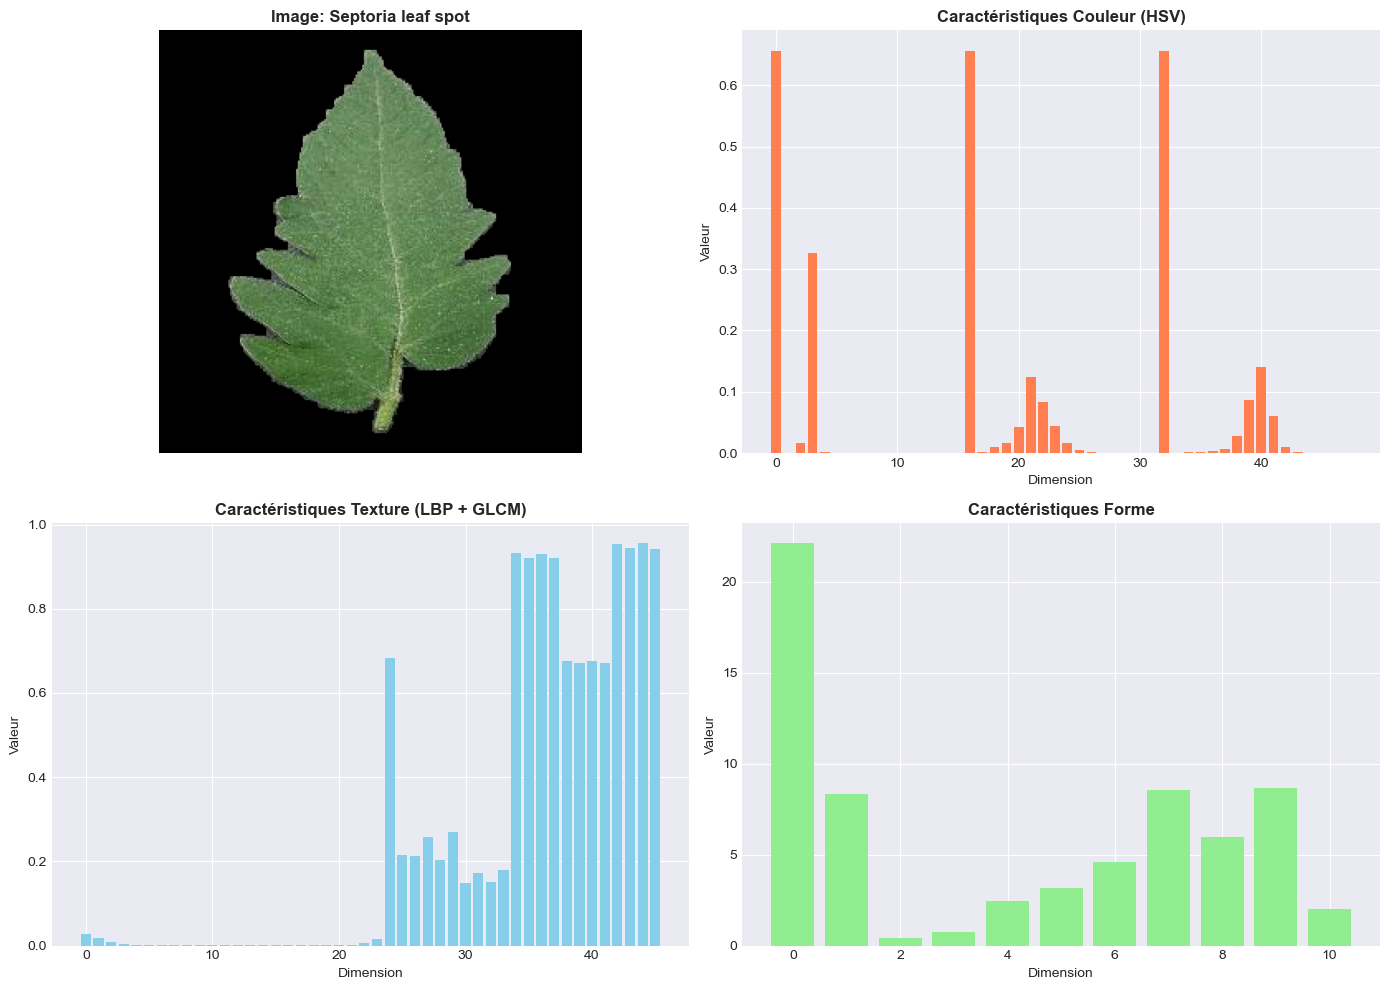


📏 DIMENSIONS DES FEATURES:
Couleur: 108 dimensions
Texture: 46 dimensions
Forme: 11 dimensions
Total: 165 dimensions


In [6]:

image_path = "data/Tomato___healthy/000bf685-b305-408b-91f4-37030f8e62db___GH_HL Leaf 308.1.jpg"
image = cv2.imread(image_path)

if image is None:
    raise ValueError("Image non chargée")

image = preprocess_image(image)
image = segment_leaf_color(image)

features = extract_all_features(image)
print("Nombre total de features :", features.shape[0])

visualize_features(image, "Septoria leaf spot")


# PARTIE 4: PRÉPARATION DU DATASET POUR L'ENTRAÎNEMENT

In [7]:
def prepare_dataset(images, labels):
    """
    Prépare le dataset complet avec extraction de features
    
    Args:
        images: liste d'images
        labels: liste de labels
    
    Returns:
        X: matrice de caractéristiques
        y: vecteur de labels encodés
        label_encoder: encodeur de labels
    """
    print("Extraction des caractéristiques en cours...")
    
    X = []
    y = []
    
    for i, (img, label) in enumerate(zip(images, labels)):
        if i % 100 == 0:
            print(f"  Traitement: {i}/{len(images)} images...")
        
        # Prétraiter l'image
        preprocessed = preprocess_image(img)
        segmented = segment_leaf_color(preprocessed)
        
        # Extraire les features
        features = extract_all_features(segmented)
        
        X.append(features)
        y.append(label)
    
    X = np.array(X)
    
    # Encoder les labels
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)
    
    print(f"\n✓ Extraction terminée!")
    print(f"Shape de X: {X.shape}")
    print(f"Shape de y: {y_encoded.shape}")
    print(f"Classes: {label_encoder.classes_}")
    
    return X, y_encoded, label_encoder

print("\n✓ Fonction de préparation du dataset définie")


    


        
        
    
    
   
    

  


✓ Fonction de préparation du dataset définie


# PARTIE 6: CLASSIFICATION ET ÉVALUATION

In [8]:
def train_and_evaluate_classifiers(X_train, X_test, y_train, y_test, label_encoder):
    """
    Entraîne et évalue différents classificateurs
    
    Args:
        X_train, X_test: données d'entraînement et de test
        y_train, y_test: labels d'entraînement et de test
        label_encoder: encodeur de labels
    
    Returns:
        dictionnaire des résultats
    """
    # Normalisation des features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Définir les classificateurs
    classifiers = {
        'SVM': SVC(kernel='rbf', C=10, gamma='scale',probability=True, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42),
        'k-NN': KNeighborsClassifier(n_neighbors=5)
    }
    
    results = {}
    
    print("\n" + "="*70)
    print("ENTRAÎNEMENT ET ÉVALUATION DES CLASSIFICATEURS")
    print("="*70)
    
    for name, clf in classifiers.items():
        print(f"\n {name}:")
        print("-" * 50)
        
        # Entraînement
        clf.fit(X_train_scaled, y_train)
        
        # Prédictions
        y_pred = clf.predict(X_test_scaled)
        
        # Métriques
        accuracy = accuracy_score(y_test, y_pred)
        
        print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
        
        # Rapport de classification
        print("\nRapport de Classification:")
        print(classification_report(y_test, y_pred, 
                                     target_names=label_encoder.classes_,
                                     digits=4))
        
        # Stocker les résultats
        results[name] = {
            'model': clf,
            'scaler': scaler,
            'accuracy': accuracy,
            'predictions': y_pred,
            'confusion_matrix': confusion_matrix(y_test, y_pred)
        }
    
    return results

def visualize_results(results, y_test, label_encoder):
    """
    Visualise les résultats de classification
    
    Args:
        results: dictionnaire des résultats
        y_test: vrais labels
        label_encoder: encodeur de labels
    """
    n_classifiers = len(results)
    fig, axes = plt.subplots(2, n_classifiers, figsize=(6*n_classifiers, 10))
    
    if n_classifiers == 1:
        axes = axes.reshape(-1, 1)
    
    class_names = [c.replace('Tomato___', '').replace('_', ' ') for c in label_encoder.classes_]
    
    for idx, (name, result) in enumerate(results.items()):
        # Matrice de confusion
        cm = result['confusion_matrix']
        
        # Normaliser la matrice de confusion
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        # Plot matrice de confusion (valeurs absolues)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=class_names,
                    yticklabels=class_names,
                    ax=axes[0, idx], cbar=True)
        axes[0, idx].set_title(f'{name}\nMatrice de Confusion (Absolue)', 
                               fontweight='bold', fontsize=12)
        axes[0, idx].set_ylabel('Vraie Classe')
        axes[0, idx].set_xlabel('Classe Prédite')
        
        # Plot matrice de confusion (normalisée)
        sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens',
                    xticklabels=class_names,
                    yticklabels=class_names,
                    ax=axes[1, idx], cbar=True, vmin=0, vmax=1)
        axes[1, idx].set_title(f'{name}\nMatrice de Confusion (Normalisée)', 
                               fontweight='bold', fontsize=12)
        axes[1, idx].set_ylabel('Vraie Classe')
        axes[1, idx].set_xlabel('Classe Prédite')
    
    plt.tight_layout()
    plt.show()
    
    # Comparaison des accuracies
    fig, ax = plt.subplots(figsize=(10, 6))
    
    names = list(results.keys())
    accuracies = [results[name]['accuracy'] * 100 for name in names]
    colors = plt.cm.viridis(np.linspace(0, 1, len(names)))
    
    bars = ax.bar(names, accuracies, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
    ax.set_title('Comparaison des Performances des Classificateurs', 
                 fontsize=14, fontweight='bold')
    ax.set_ylim([0, 100])
    ax.axhline(y=80, color='r', linestyle='--', label='Objectif 80%')
    
    # Ajouter les valeurs sur les barres
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{acc:.2f}%',
                ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    ax.legend()
    plt.tight_layout()
    plt.show()

print("\n Fonctions de classification et évaluation définies")



 Fonctions de classification et évaluation définies


# PARTIE 7: PIPELINE COMPLET D'EXÉCUTION


 EXÉCUTION DU PIPELINE COMPLET

 Chargement du dataset...
Extraction des caractéristiques en cours...
  Traitement: 0/1573 images...
  Traitement: 100/1573 images...
  Traitement: 200/1573 images...
  Traitement: 300/1573 images...
  Traitement: 400/1573 images...
  Traitement: 500/1573 images...
  Traitement: 600/1573 images...
  Traitement: 700/1573 images...
  Traitement: 800/1573 images...
  Traitement: 900/1573 images...
  Traitement: 1000/1573 images...
  Traitement: 1100/1573 images...
  Traitement: 1200/1573 images...
  Traitement: 1300/1573 images...
  Traitement: 1400/1573 images...
  Traitement: 1500/1573 images...

✓ Extraction terminée!
Shape de X: (1573, 165)
Shape de y: (1573,)
Classes: ['Tomato___Bacterial_spot' 'Tomato___Septoria_leaf_spot'
 'Tomato___Tomato_mosaic_virus' 'Tomato___healthy']

 Dataset préparé :
   - Images traitées : 1573
   - Features par image : 165
   - Classes : 4

 Division du dataset:
  Training set: 1258 images
  Test set: 315 images

ENTRAÎNEM

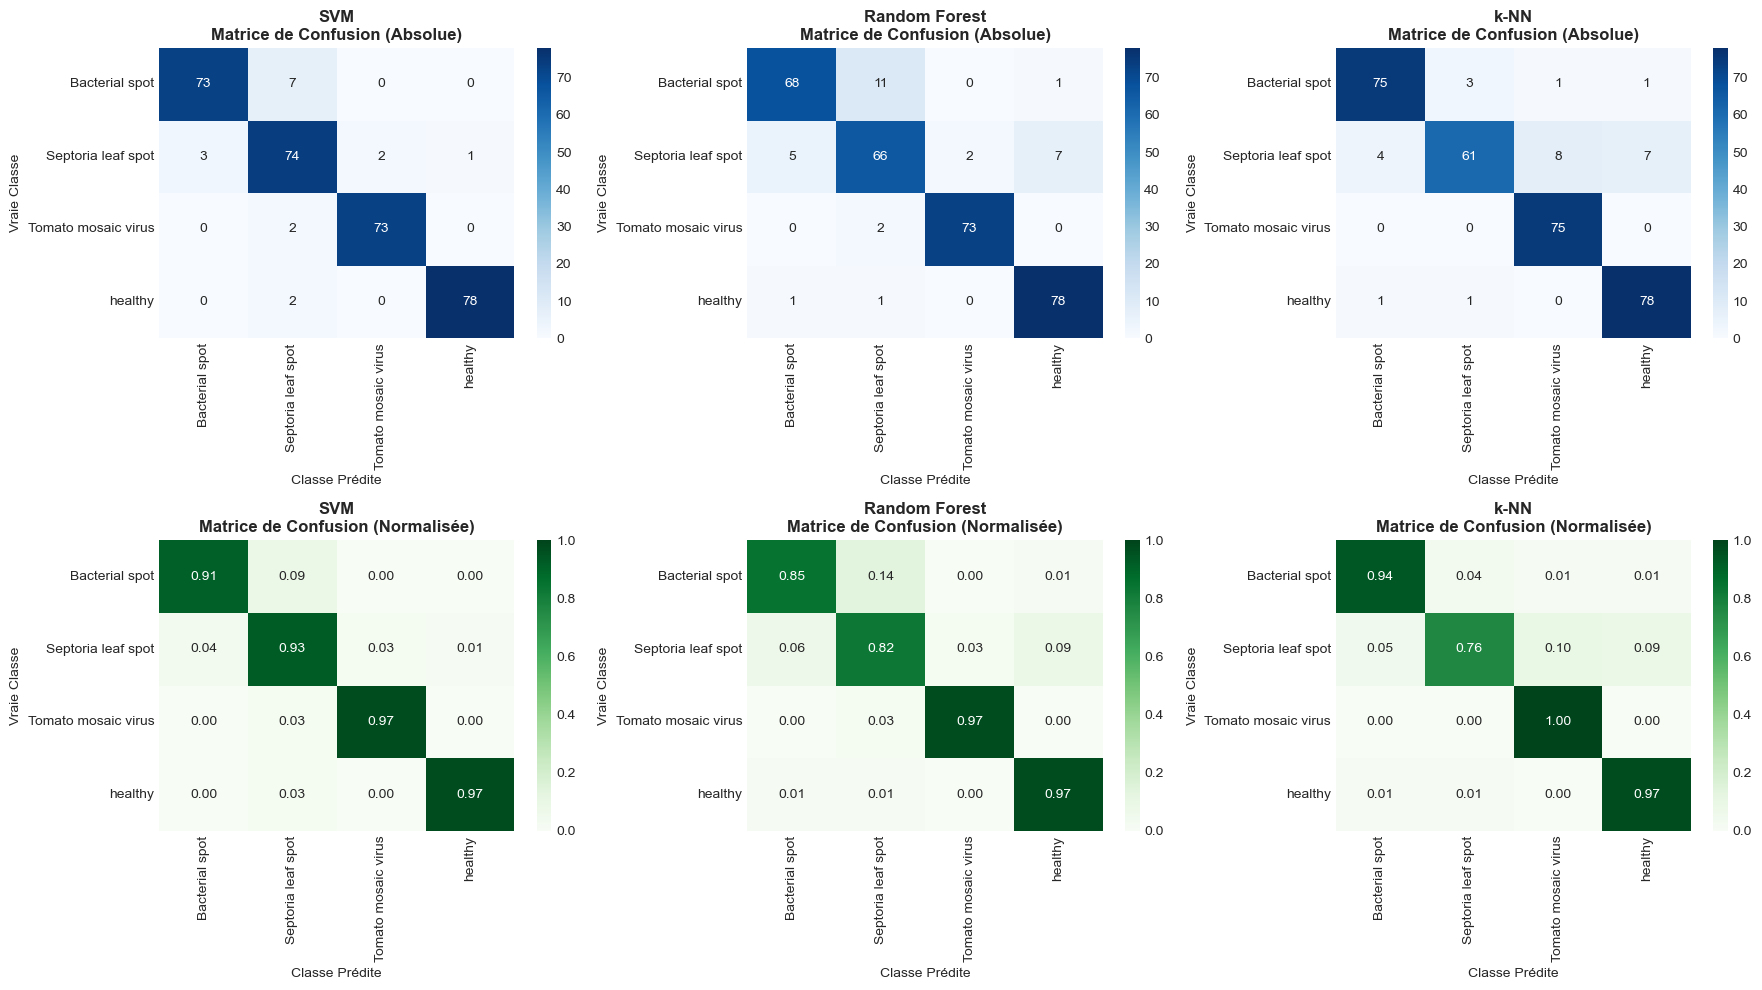

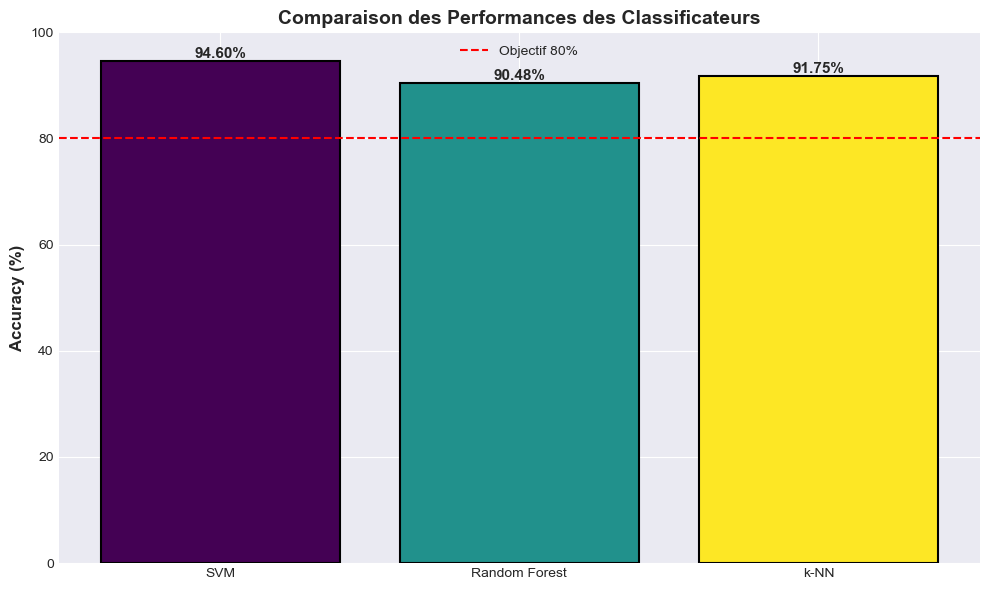


 Meilleur modèle SVM


In [9]:
print("\n" + "="*70)
print(" EXÉCUTION DU PIPELINE COMPLET")
print("="*70)

# EXEMPLE D'UTILISATION (décommenter et adapter selon vos chemins)

# 1. Charger le dataset
print("\n Chargement du dataset...")
images, labels = load_dataset(BASE_PATH, max_images_per_class=400)  # Équilibrage à 400 images/classe

# 2. Préparer les features
X, y, label_encoder = prepare_dataset(images, labels)

# 2.1. Vérifier les résultats
print(f"\n Dataset préparé :")
print(f"   - Images traitées : {X.shape[0]}")
print(f"   - Features par image : {X.shape[1]}")
print(f"   - Classes : {len(label_encoder.classes_)}")

# 3. Division train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n Division du dataset:")
print(f"  Training set: {len(X_train)} images")
print(f"  Test set: {len(X_test)} images")

# 4. Entraîner et évaluer les modèles
results = train_and_evaluate_classifiers(X_train, X_test, y_train, y_test, label_encoder)

# 5. Visualiser les résultats
visualize_results(results, y_test, label_encoder)

# 6. Sauvegarder le meilleur modèle
import pickle

best_model_name = max(results, key=lambda k: results[k]['accuracy'])
best_model = results[best_model_name]['model']
best_scaler = results[best_model_name]['scaler']

with open('best_model.pkl', 'wb') as f:
    pickle.dump({
        'model': best_model,
        'scaler': best_scaler,
        'label_encoder': label_encoder
    }, f)

print(f"\n Meilleur modèle {best_model_name}")